In [1]:
import tensorflow as tf

from sklearn import metrics

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input,BatchNormalization
from keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_preprocessing import preprocess_normal


In [2]:
xtrain, xval, xtest, ytrain, yval,ytest, scaler, le = preprocess_normal("datasets/normal")



[Normal] classes：['downstairs', 'jump', 'run', 'upstairs', 'walk'], train：3925, val：1309, test：1309


In [3]:
model = Sequential([
    Input(shape=(xtrain.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax'),
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               640       
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [4]:
model.compile(optimizer='adam',
              loss='SparseCategoricalCrossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(xtrain, ytrain, batch_size=64, epochs=1000,
                    validation_data=(xval, yval),
                    callbacks=[early_stop])


Epoch 1/1000
62/62 [==============================] - 2s 5ms/step - loss: 1.0190 - accuracy: 0.5939 - val_loss: 1.0614 - val_accuracy: 0.6684
Epoch 2/1000
62/62 [==============================] - 0s 4ms/step - loss: 0.5939 - accuracy: 0.7610 - val_loss: 0.9417 - val_accuracy: 0.6753
Epoch 3/1000
62/62 [==============================] - 0s 4ms/step - loss: 0.5176 - accuracy: 0.7954 - val_loss: 0.7751 - val_accuracy: 0.7273
Epoch 4/1000
62/62 [==============================] - 0s 3ms/step - loss: 0.4854 - accuracy: 0.8082 - val_loss: 0.5769 - val_accuracy: 0.7991
Epoch 5/1000
62/62 [==============================] - 0s 4ms/step - loss: 0.4419 - accuracy: 0.8209 - val_loss: 0.3997 - val_accuracy: 0.8739
Epoch 6/1000
62/62 [==============================] - 0s 4ms/step - loss: 0.4145 - accuracy: 0.8357 - val_loss: 0.3436 - val_accuracy: 0.8961
Epoch 7/1000
62/62 [==============================] - 0s 4ms/step - loss: 0.4050 - accuracy: 0.8431 - val_loss: 0.3486 - val_accuracy: 0.8717
Epoch 

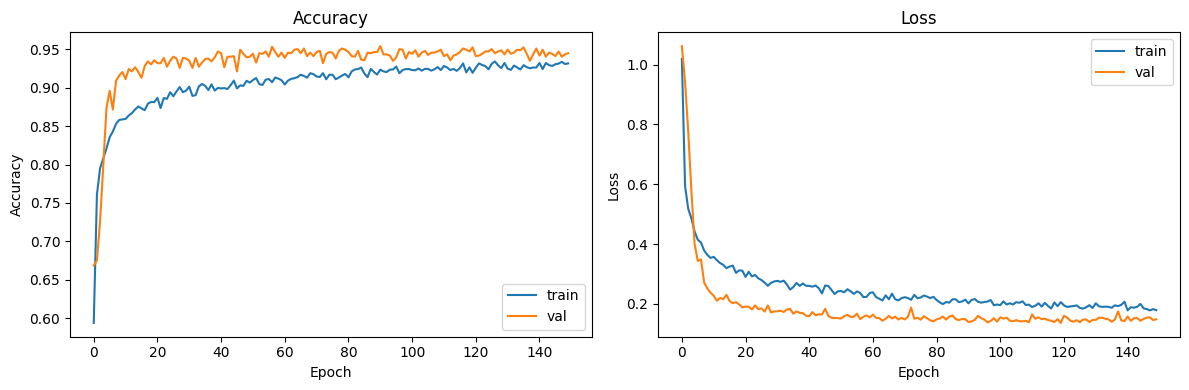

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('./image/MLP_NormalGait_AccLoss.jpg', dpi=500, bbox_inches='tight')
plt.show()


In [6]:
eval_loss, eval_accuracy = model.evaluate(xtest, ytest)
print(f"Test Loss: {eval_loss:.4f}  |  Test Accuracy: {eval_accuracy:.4f}")

41/41 [==============================] - 0s 1ms/step - loss: 0.1346 - accuracy: 0.9465
Test Loss: 0.1346  |  Test Accuracy: 0.9465


In [7]:
# save model 
model.save("./model/MLP_Model.h5")

In [8]:
y_pred=np.argmax(model.predict(xtest), axis=-1)
y_true=ytest
matrix = metrics.confusion_matrix(y_true, y_pred)
labels = list(le.classes_)

41/41 [==============================] - 0s 812us/step


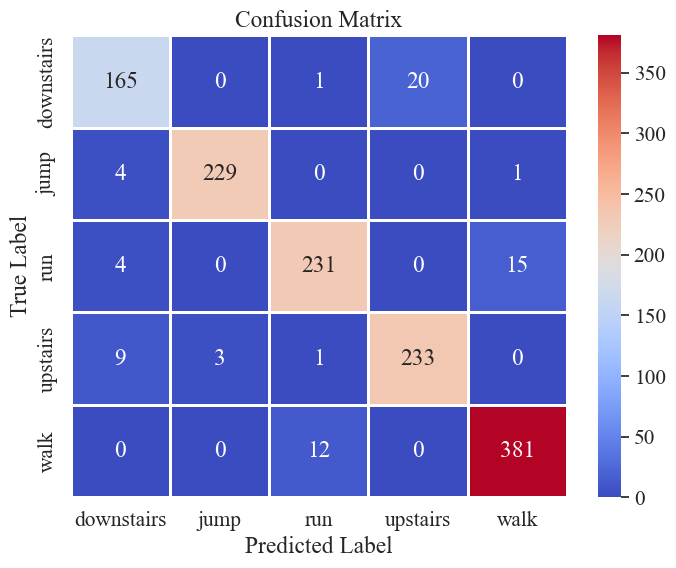

In [9]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid",font='Times New Roman',font_scale=1.4)
sns.heatmap(matrix,
            cmap="coolwarm",
            linecolor='white',
            linewidths=1,
            xticklabels=labels,
            yticklabels=labels,
            annot=True,
            fmt="d")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")

image_path = './image/MLP_NormalGait_CM.jpg'
plt.savefig(image_path, dpi=500, bbox_inches='tight')  #sava image
plt.show()